<a href="https://colab.research.google.com/github/sikandermukhtar/text-classification/blob/main/text_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing libraries**

In [ ]:
import re

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from wordcloud import WordCloud

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
from sentence_transformers import SentenceTransformer

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

**Loading dataset**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/datasets/IMDB Dataset.csv')

In [ ]:
df.head()

,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her ""sexy"" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than ""Devil Wears Prada"" and more interesting than ""Superman"" a great comedy to go see with friends.",positive
3,"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zom

**Checking classes balance**

In [ ]:
print(df['sentiment'].value_counts())

# Percentage of each class
print(df['sentiment'].value_counts(normalize=True) * 100)

sentiment
positive    25000
negative    25000
Name: count, dtype: int64
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


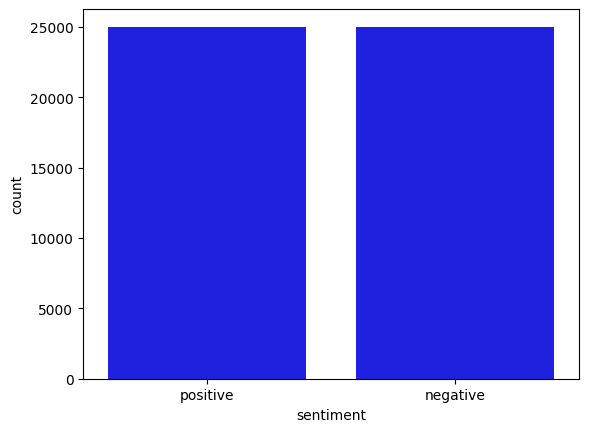

In [ ]:
sns.countplot(x='sentiment', data=df, color='blue')
plt.show()

**Word Cloud**

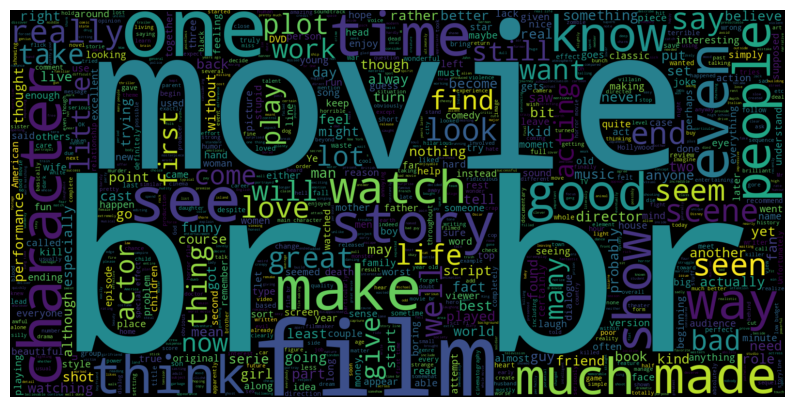

In [ ]:
plt.figure(figsize=(10, 8))
wc = WordCloud(max_words=1000, width=1600, height=800).generate(" ".join(df['review']))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

**Check for duplicates**

In [ ]:
print(f"No. of duplicate rows in dataset: {df.duplicated().sum()}")

No. of duplicate rows in dataset: 418


In [ ]:
df.drop_duplicates(inplace = True)

**Check for missing values**

In [ ]:
print(f"No. of rows with missing values: {df.isna().sum()}")

No. of rows with missing values: review       0
sentiment    0
dtype: int64


**Label encoding target column**

In [ ]:
le = LabelEncoder()

In [ ]:
df['sentiment'] = le.fit_transform(df['sentiment'])

In [ ]:
df

,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",1
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.",1
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her ""sexy"" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than ""Devil Wears Prada"" and more interesting than ""Superman"" a great comedy to go see with friends.",1
3,"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, f

**Text Preprocessing**

**Removing HTML tags**

In [ ]:
def remove_html_tags(text):
  pattern = re.compile(r'<.*?>')
  return pattern.sub(r'', text)

In [ ]:
df['review'] = df['review'].apply(remove_html_tags)

In [ ]:
def remove_url(text):
    pattern = re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(r'', text)

In [ ]:
df['review'] = df['review'].apply(remove_url)

**Word Cloud after text cleaning**

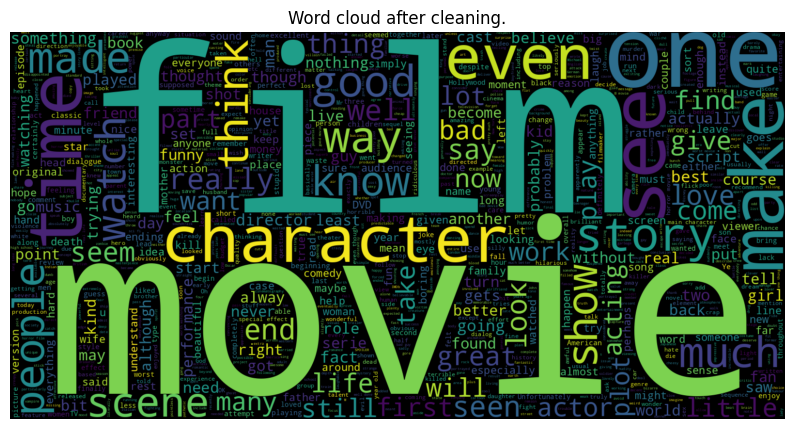

In [ ]:
plt.figure(figsize=(10, 8))
wc = WordCloud(max_words=1000, width=1600, height=800).generate(" ".join(df['review']))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word cloud after cleaning.")
plt.show()

**Creating embedding of text**

In [ ]:
# embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

In [ ]:
# embeddings = embedding_model.encode(
#     df['review'].tolist(),
#     batch_size = 128,
#     show_progress_bar = True,
#     convert_to_numpy = True
# )

In [ ]:
embeddings = np.load('/content/drive/MyDrive/datasets/imdb_embeddings.npy')

**Embeddings shape**

In [ ]:
print("Embedding shape:", embeddings.shape)

Embedding shape: (49582, 384)


In [ ]:
df['sentiment'].shape

(49582,)

**Splitting dataset**

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    embeddings, df['sentiment'], test_size=0.1, random_state=42
)

**Building model**

## Baseline - Logistic Regression

In [ ]:
logistic_regression = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)

**Fitting model**

In [ ]:
logistic_regression.fit(X_train, y_train)

LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)

**Model prediction**

In [ ]:
y_val_probs = logistic_regression.predict_proba(X_val)[:, 1]

In [ ]:
y_val_pred = (y_val_probs > 0.5).astype(int)

**Model Accuracy**

In [ ]:
lr_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

Logistic Regression Accuracy: 0.8205


**Classification report**

In [ ]:
print("\nClassification Report:\n", classification_report(y_val, y_val_pred, digits=4))


Classification Report:
               precision    recall  f1-score   support

           0     0.8231    0.8179    0.8205      2487
           1     0.8179    0.8232    0.8206      2472

    accuracy                         0.8205      4959
   macro avg     0.8205    0.8205    0.8205      4959
weighted avg     0.8205    0.8205    0.8205      4959



**Confusion matrix**

In [ ]:
lr_cm = confusion_matrix(y_val, y_val_pred)
print("Confusion Matrix:\n", lr_cm)

Confusion Matrix:
 [[2034  453]
 [ 437 2035]]


<Axes: >

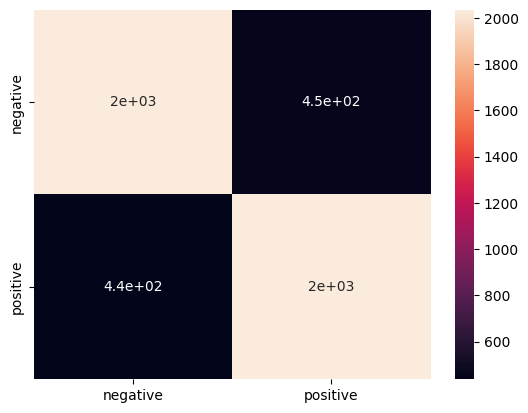

In [ ]:
sns.heatmap(lr_cm, annot=True, xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])

# ANN

In [ ]:
ann_model = models.Sequential([
    layers.Input(shape=(384,)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

In [ ]:
ann_model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

**Early stopping**

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
history = ann_model.fit(X_train, y_train, batch_size=1024, epochs=100, validation_split=0.1, callbacks=[early_stopping])

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6707 - loss: 0.6257 - val_accuracy: 0.7943 - val_loss: 0.4384
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7989 - loss: 0.4322 - val_accuracy: 0.8192 - val_loss: 0.4129
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8114 - loss: 0.4071 - val_accuracy: 0.8230 - val_loss: 0.4035
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8199 - loss: 0.3940 - val_accuracy: 0.8266 - val_loss: 0.3974
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8247 - loss: 0.3840 - val_accuracy: 0.8255 - val_loss: 0.3938
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8320 - loss: 0.3752 - val_accuracy: 0.8290 - val_loss: 0.3898
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8349 - loss: 0.3681 - val_accuracy: 0.8342 - val_loss: 0.3851
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8444 - loss: 0.3534 - val_accuracy: 0.

**Trainig graph**

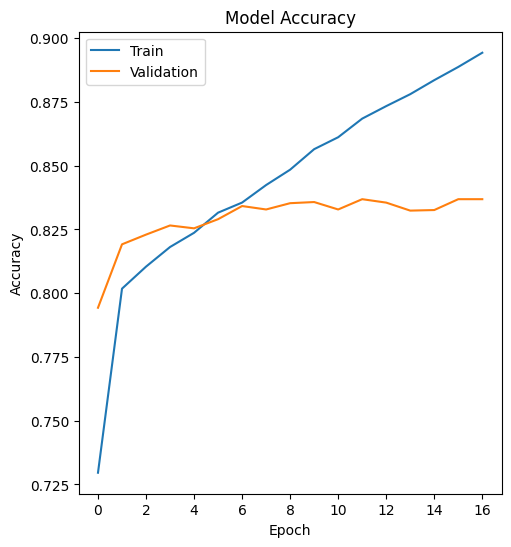

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

**Model prediction**

In [ ]:
y_val_probs = ann_model.predict(X_val, batch_size=1024)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [ ]:
y_val_pred = (y_val_probs > 0.5).astype(int)

**Model Accuracy**

In [ ]:
ann_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Model Accuracy: {ann_accuracy:.4f}")

Model Accuracy: 0.8373


**Classification Report**

In [ ]:
print("\nClassification Report:\n", classification_report(y_val, y_val_pred, digits=4))


Classification Report:
               precision    recall  f1-score   support

           0     0.8281    0.8524    0.8401      2487
           1     0.8470    0.8220    0.8343      2472

    accuracy                         0.8373      4959
   macro avg     0.8376    0.8372    0.8372      4959
weighted avg     0.8375    0.8373    0.8372      4959



**Confusion Matrix**

In [ ]:
ann_cm = confusion_matrix(y_val, y_val_pred)
print("Confusion Matrix:\n", ann_cm)

Confusion Matrix:
 [[2120  367]
 [ 440 2032]]


<Axes: >

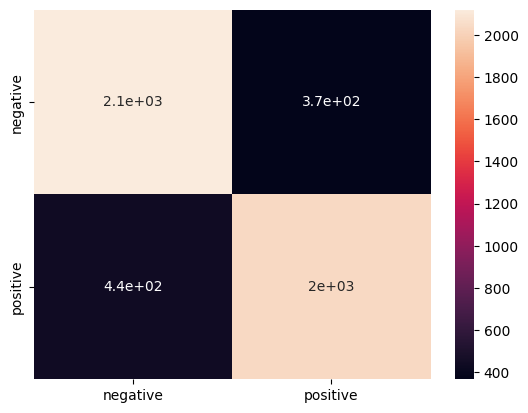

In [ ]:
sns.heatmap(ann_cm, annot=True, xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])

# XGBoost

**Importing XGBoostClassifier**

In [ ]:
from xgboost import XGBClassifier

**Defining XGB Classifer**

In [ ]:
xgb_classifier = XGBClassifier(
    n_estimators=500,
    early_stopping_rounds=10,
    max_depth=6,
    learning_rate = 0.005,
    eval_metric='logloss'
)

**Fitting XGBoost Classifier**

In [ ]:
xgb_classifier.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=1)

[0]	validation_0-logloss:0.69234
[1]	validation_0-logloss:0.69152
[2]	validation_0-logloss:0.69070
[3]	validation_0-logloss:0.68986
[4]	validation_0-logloss:0.68907
[5]	validation_0-logloss:0.68821
[6]	validation_0-logloss:0.68736
[7]	validation_0-logloss:0.68658
[8]	validation_0-logloss:0.68575
[9]	validation_0-logloss:0.68498
[10]	validation_0-logloss:0.68418
[11]	validation_0-logloss:0.68340
[12]	validation_0-logloss:0.68264
[13]	validation_0-logloss:0.68186
[14]	validation_0-logloss:0.68109
[15]	validation_0-logloss:0.68035
[16]	validation_0-logloss:0.67960
[17]	validation_0-logloss:0.67884
[18]	validation_0-logloss:0.67810
[19]	validation_0-logloss:0.67737
[20]	validation_0-logloss:0.67665
[21]	validation_0-logloss:0.67593
[22]	validation_0-logloss:0.67522
[23]	validation_0-logloss:0.67447
[24]	validation_0-logloss:0.67375
[25]	validation_0-logloss:0.67304
[26]	validation_0-logloss:0.67230
[27]	validation_0-logloss:0.67162
[28]	validation_0-logloss:0.67091
[29]	validation_0-loglos

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.005, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

**Model Prediction**

In [ ]:
y_pred_xgb = xgb_classifier.predict(X_val)

**XGBoost Evaluation**

**Model Accuracy**

In [ ]:
xgb_accuracy = accuracy_score(y_val, y_pred_xgb)
print(f"Accuracy: {xgb_accuracy:.4f}")

Accuracy: 0.7473


**Classification Report**

In [ ]:
print("\nClassification Report:\n", classification_report(y_val, y_pred_xgb))


Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.74      0.75      2487
           1       0.74      0.75      0.75      2472

    accuracy                           0.75      4959
   macro avg       0.75      0.75      0.75      4959
weighted avg       0.75      0.75      0.75      4959



**Confusion Matrix**

In [ ]:
cm_xgb = confusion_matrix(y_val, y_pred_xgb)
print("Confusion Matrix:\n", cm_xgb)

Confusion Matrix:
 [[1852  635]
 [ 618 1854]]


<Axes: >

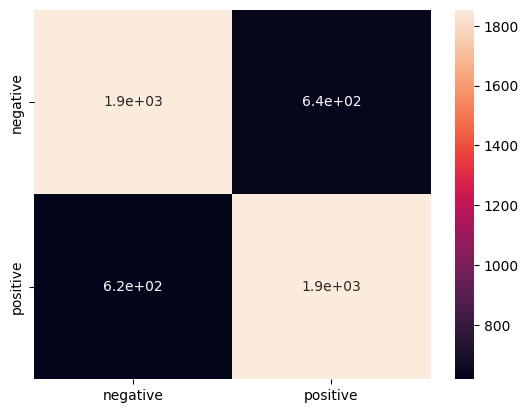

In [ ]:
sns.heatmap(cm_xgb, annot=True, xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])

In [ ]:
results = {
    "Model" : ["Logistic Regression", "ANN", "XGBoost"],
    "Accuracy": [lr_accuracy, ann_accuracy, xgb_accuracy],
    "Remarks": ["Baseline model, simple, performed surprisingly well", "More accurate and faster than XGB", "Performed poorer than expected, slower (500 estimators)"]
}

In [ ]:
df_results = pd.DataFrame(results)

# Model Comparison

In [ ]:
df_results

,Model,Accuracy,Remarks
0,Logistic Regression,0.820528,"Baseline model, simple, performed surprisingly well"
1,ANN,0.837266,More accurate and faster than XGB
2,XGBoost,0.747328,"Performed poorer than expected, slower (500 estimators)"


**Exporting using joblib**

In [ ]:
import joblib

In [ ]:
joblib.dump(ann_model, "imdb_classifier.pkl")
joblib.dump(logistic_regression, "lr_imdb_classifier.pkl")
joblib.dump(xgb_classifier, "xgb_imdb_classifier.pkl")

['xgb_imdb_classifier.pkl']

In [ ]:
from google.colab import files
files.download("imdb_classifier.pkl")
files.download("lr_imdb_classifier.pkl")
files.download("xgb_imdb_classifier.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>